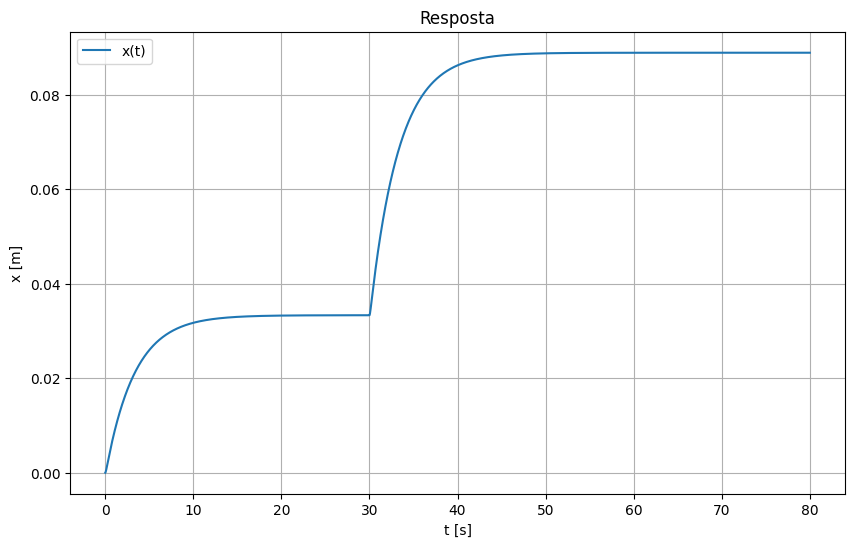

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

# -------------------------
# Dades exercici
# -------------------------
R = 60e-3             # m, radi politja
m = 500e-3            # kg, massa bloc
J = 100e-3/2 * R**2   # kg·m2, inercia politja
c = 10                # Ns/m, esmorteïment
k1 = 1                # N/m, rigidesa
k2 = 2                # N/m, rigidesa

x0 = 50e-3            # m, pretensio
M = 10e-3             # Nm, moment M(t)

# -------------------------
# Sistema equivalent
# -------------------------
m_eq = m + J/R**2
c_eq = c
k_eq = k1 + k2

x1_0 = 2*k1/(k1+k2)*x0
x2_0 = 2*k2/(k1+k2)*x0

# força equivalent de les condicions inicials
Q_x0 = -k1*x1_0 + k2*x2_0

# -------------------------
# Excitació
# -------------------------
def torque(t):
    if t >= 30:
        return M/R
    else:
        return 0

def Q(t):
    return torque(t) + Q_x0

# -------------------------
# Sistema d'EDO
# -------------------------
def system(t, y):
    x = y[0]
    v = y[1]

    dxdt = v
    dvdt = (Q(t) - c_eq*v - k_eq*x)/m_eq

    return [dxdt, dvdt]

# -------------------------
# Simulació
# -------------------------
t_span = (0,80)
t_eval = np.linspace(0,80,2000)

sol = solve_ivp(system, t_span, [0,0], t_eval=t_eval)

plt.figure(figsize=(10,6))
plt.plot(sol.t, sol.y[0], label="x(t)")
plt.xlabel("t [s]")
plt.ylabel("x [m]")
plt.title("Resposta")
plt.grid(True)
plt.legend()
plt.show()

In [2]:
# -------------------------
# Teorema valor inicial i final
# -------------------------
s = sp.symbols('s')

F_0  = (-k1*x1_0 + k2*x2_0)/(s**2*m_eq + c_eq*s + k_eq)*(1/s)
F_tau = (sp.exp(-20*s)*M/R)/(s**2*m_eq + c_eq*s + k_eq)*(1/s)

F = F_0 + F_tau

initial_value_tau = sp.limit(s*F_tau, s, sp.oo)
final_value_tau =   sp.limit(s*F_tau, s, 0)

print("Aplicant només moment M(t)")
print("-"*50)
print("Valor inicial sense CI:", float(initial_value_tau),"m")
print("Valor final sense CI  :", round(float(final_value_tau),4),"m \n")

initial_value = sp.limit(s*F, s, sp.oo)
final_value =   sp.limit(s*F, s, 0)

print("Aplicant condicions inicials i moment M(t)")
print("-"*50)
print("Valor inicial:", float(initial_value),"m")
print("Valor final:  ", round(float(final_value),4),"m \n")

Aplicant només moment M(t)
--------------------------------------------------
Valor inicial sense CI: 0.0 m
Valor final sense CI  : 0.0556 m 

Aplicant condicions inicials i moment M(t)
--------------------------------------------------
Valor inicial: 0.0 m
Valor final:   0.0889 m 

